In [2]:
!pip install -q kagglehub

In [3]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "nandeeshhu/pancrease-ct-segmenatation"
)

print("Dataset Path:", dataset_path)

100%|██████████| 1.67G/1.67G [01:39<00:00, 18.0MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/nandeeshhu/pancrease-ct-segmenatation/versions/1


In [4]:
import os

print(os.listdir(dataset_path))

['images', 'masks']


In [5]:
images_path = os.path.join(dataset_path, "images")
masks_path = os.path.join(dataset_path, "masks")

print("Images folders:", os.listdir(images_path))
print("Masks folders :", os.listdir(masks_path))

Images folders: ['negative', 'positive']
Masks folders : ['negative', 'positive']


In [6]:
positive_images = len(os.listdir(os.path.join(images_path, "positive")))
negative_images = len(os.listdir(os.path.join(images_path, "negative")))

positive_masks = len(os.listdir(os.path.join(masks_path, "positive")))
negative_masks = len(os.listdir(os.path.join(masks_path, "negative")))

print("Positive Images :", positive_images)
print("Negative Images :", negative_images)

print("Positive Masks  :", positive_masks)
print("Negative Masks  :", negative_masks)

Positive Images : 6882
Negative Images : 12060
Positive Masks  : 6882
Negative Masks  : 12060


Image Size: (512, 512)
Image Mode: L


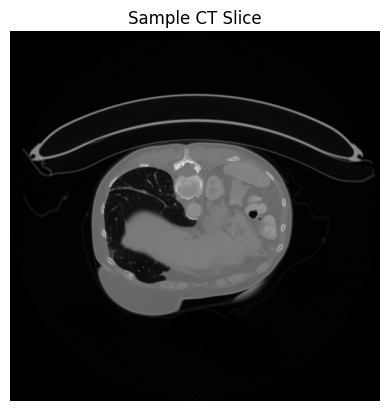

In [7]:
from PIL import Image
import matplotlib.pyplot as plt
import os

sample_image = os.path.join(
    images_path,
    "positive",
    os.listdir(os.path.join(images_path, "positive"))[0]
)

img = Image.open(sample_image)

print("Image Size:", img.size)
print("Image Mode:", img.mode)

plt.imshow(img, cmap="gray")
plt.title("Sample CT Slice")
plt.axis("off")
plt.show()

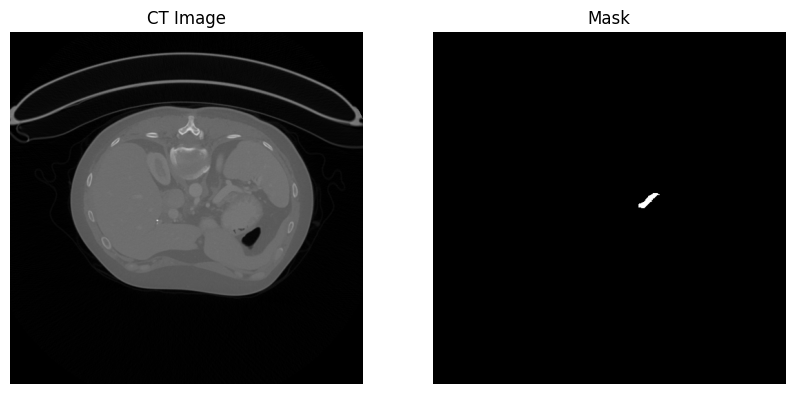

Image: img_00099.png
Mask : mask_00099.png


In [8]:
from PIL import Image
import matplotlib.pyplot as plt
import os

image_file = sorted(
    os.listdir(os.path.join(images_path, "positive"))
)[0]

mask_file = sorted(
    os.listdir(os.path.join(masks_path, "positive"))
)[0]

image_path = os.path.join(
    images_path,
    "positive",
    image_file
)

mask_path = os.path.join(
    masks_path,
    "positive",
    mask_file
)

image = Image.open(image_path)
mask = Image.open(mask_path)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image, cmap="gray")
plt.title("CT Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

print("Image:", image_file)
print("Mask :", mask_file)

In [9]:
import numpy as np
import tensorflow as tf

from PIL import Image
from sklearn.model_selection import train_test_split

In [10]:
positive_paths = [
    os.path.join(images_path, "positive", f)
    for f in os.listdir(os.path.join(images_path, "positive"))
]

negative_paths = [
    os.path.join(images_path, "negative", f)
    for f in os.listdir(os.path.join(images_path, "negative"))
]

image_paths = positive_paths + negative_paths

labels = (
    [1] * len(positive_paths) +
    [0] * len(negative_paths)
)

print("Total Images:", len(image_paths))
print("Total Labels:", len(labels))

Total Images: 18942
Total Labels: 18942


In [11]:
print("First Positive Label :", labels[0])

print(
    "First Negative Label :",
    labels[len(positive_paths)]
)

First Positive Label : 1
First Negative Label : 0


In [12]:
IMG_SIZE = 256

def load_image(image_path):
    image = Image.open(image_path)

    image = image.resize((IMG_SIZE, IMG_SIZE))

    image = np.array(image, dtype=np.float32)

    image = image / 255.0

    return image

In [13]:
sample = load_image(image_paths[0])

print("Shape :", sample.shape)

print("Min :", sample.min())

print("Max :", sample.max())

Shape : (256, 256)
Min : 0.0
Max : 0.8980392


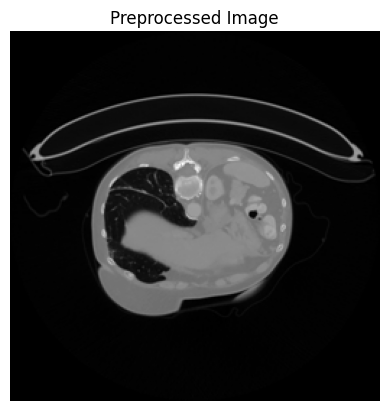

In [14]:
plt.imshow(sample, cmap="gray")
plt.title("Preprocessed Image")
plt.axis("off")
plt.show()

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 15153
Testing Samples  : 3789


In [16]:
def process_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_png(
        image,
        channels=1
    )

    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    return image, label

In [17]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)

train_ds = train_ds.map(
    process_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds = test_ds.map(
    process_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.batch(32).prefetch(
    tf.data.AUTOTUNE
)

test_ds = test_ds.batch(32).prefetch(
    tf.data.AUTOTUNE
)

print("Dataset pipeline created.")

Dataset pipeline created.


In [18]:
for images, labels in train_ds.take(1):

    print("Image Batch Shape :", images.shape)

    print("Label Batch Shape :", labels.shape)

    print("First Label :", labels[0].numpy())

Image Batch Shape : (32, 256, 256, 1)
Label Batch Shape : (32,)
First Label : 0


In [19]:
from tensorflow.keras import layers
from tensorflow.keras import models

cnn_model = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(256,256,1)
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        128,
        (3,3),
        activation="relu"
    ),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        1,
        activation="sigmoid"
    )
])

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,838,529 (56.60 MB)

 Trainable params: 14,838,529 (56.60 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
cnn_model.compile(
    optimizer="adam",

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("CNN compiled successfully.")

CNN compiled successfully.


In [21]:
val_size = int(0.1 * len(X_train))

X_val = X_train[:val_size]
y_val = y_train[:val_size]

X_train_new = X_train[val_size:]
y_train_new = y_train[val_size:]

print("Train:", len(X_train_new))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Train: 13638
Validation: 1515
Test: 3789


In [22]:
val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
)

val_ds = val_ds.map(
    process_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.batch(32).prefetch(
    tf.data.AUTOTUNE
)

print("Validation dataset created.")

Validation dataset created.


In [23]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [24]:
history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 74s 129ms/step - accuracy: 0.8439 - loss: 0.3167 - precision: 0.7903 - recall: 0.7764 - val_accuracy: 0.9149 - val_loss: 0.1947 - val_precision: 0.8192 - val_recall: 0.9779
Epoch 2/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 46s 98ms/step - accuracy: 0.9528 - loss: 0.1221 - precision: 0.9283 - recall: 0.9430 - val_accuracy: 0.9723 - val_loss: 0.0755 - val_precision: 0.9386 - val_recall: 0.9871
Epoch 3/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 82s 99ms/step - accuracy: 0.9723 - loss: 0.0732 - precision: 0.9592 - recall: 0.9649 - val_accuracy: 0.9782 - val_loss: 0.0586 - val_precision: 0.9687 - val_recall: 0.9705
Epoch 4/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 83s 101ms/step - accuracy: 0.9801 - loss: 0.0556 - precision: 0.9719 - recall: 0.9735 - val_accuracy: 0.9861 - val_loss: 0.0395 - val_precision: 0.9694 - val_recall: 0.9926
Epoch 5/10
474/474 ━━━━━━━━━━━━━━━━━━━━ 81s 100ms/step - accuracy: 0.9828 - loss: 0.0470 - precision: 0.9759 - recall: 0.9767 - val_accuracy: 0.9888 -

In [25]:
test_results = cnn_model.evaluate(test_ds)

print("\nTest Results")
print("-" * 30)

for name, value in zip(
    cnn_model.metrics_names,
    test_results
):
    print(f"{name}: {value:.4f}")

119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 93ms/step - accuracy: 0.9850 - loss: 0.0407 - precision: 0.9783 - recall: 0.9804

Test Results
------------------------------
loss: 0.0407
compile_metrics: 0.9850


In [26]:
cnn_model.save("classifier.keras")

print("Classifier saved successfully.")

Classifier saved successfully.
